In [14]:
!pip install tensorflow keras opencv-python scikit-image imutils

In [15]:
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import random

def generate_base_receipt(w=400, h=600):
    # Create a white background
    img = Image.new('L', (w, h), 255)
    draw = ImageDraw.Draw(img)
    
    # Add dummy text (mimicking a mall receipt)
    text_content = [
        "MALL CENTRAL", "STORE #402", "----------------",
        "ITEM A    $25.00", "ITEM B    $12.99", "ITEM C    $05.50",
        "----------------", "TOTAL     $43.49", "THANK YOU!"
    ]
    
    y_pos = 40
    for line in text_content:
        # Drawing with default font; for better results, path to a monospace .ttf
        draw.text((50, y_pos), line, fill=0)
        y_pos += 40
        
    return cv2.cvtColor(np.array(img), cv2.COLOR_GRAY2BGR)
def apply_distortions(img):
    h, w = img.shape[:2]
    
    # 1. Skew/Rotation
    angle = random.uniform(-10, 10)
    M_rot = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    skewed = cv2.warpAffine(img, M_rot, (w, h), borderValue=(255, 255, 255))
    
    # 2. Perspective Distortion (The "Folded" or "Angled" look)
    pts1 = np.float32([[0,0], [w,0], [0,h], [w,h]])
    # Shift corners randomly by up to 15%
    pts2 = np.float32([
        [random.randint(0, 40), random.randint(0, 40)],
        [w - random.randint(0, 40), random.randint(0, 40)],
        [random.randint(0, 40), h - random.randint(0, 40)],
        [w - random.randint(0, 40), h - random.randint(0, 40)]
    ])
    M_persp = cv2.getPerspectiveTransform(pts1, pts2)
    perspective = cv2.warpPerspective(img, M_persp, (w, h), borderValue=(255, 255, 255))
    
    # 3. Noise & Fade (Simulating thermal print degradation)
    noise = np.random.randint(0, 50, (h, w, 3), dtype='uint8')
    noisy = cv2.add(img, noise)
    
    return skewed, perspective, noisy
    # Execution
base_receipt = generate_base_receipt()
skewed, perspective, noisy = apply_distortions(base_receipt)

# Save samples
cv2.imwrite("receipt_skewed.jpg", skewed)
cv2.imwrite("receipt_perspective.jpg", perspective)
cv2.imwrite("receipt_noisy.jpg", noisy)

True

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def order_points(pts):
    """
    Orders points in the following order:
    top-left, top-right, bottom-right, bottom-left
    """
    rect = np.zeros((4, 2), dtype="float32")

    # Sum and difference of points
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)

    # Assign corners
    rect[0] = pts[np.argmin(s)]      # Top-left
    rect[2] = pts[np.argmax(s)]      # Bottom-right
    rect[1] = pts[np.argmin(diff)]   # Top-right
    rect[3] = pts[np.argmax(diff)]   # Bottom-left

    return rect
def four_point_transform(image, pts):
    """
    Applies perspective transform to obtain a top-down view
    of the image based on 4 input points.
    """
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    # Compute width
    widthA = np.linalg.norm(br - bl)
    widthB = np.linalg.norm(tr - tl)
    maxWidth = max(int(widthA), int(widthB))

    # Compute height
    heightA = np.linalg.norm(tr - br)
    heightB = np.linalg.norm(tl - bl)
    maxHeight = max(int(heightA), int(heightB))

    # Destination points
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]
    ], dtype="float32")
     # Perspective transform
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))

    return warped

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("/kaggle/input/datasets/musfiranazahat/kuchbhaiye/images/11.jpg")

if image is None:
    raise ValueError("Image not found. Check path.")

# Convert BGR → RGB (for matplotlib display)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Manually define 4 corner points (adjust based on your image)
pts = np.array([
    [100, 100],   # Top-left
    [500, 80],    # Top-right
    [520, 700],   # Bottom-right
    [120, 720]    # Bottom-left
], dtype="float32")

# Apply perspective transform
warped = four_point_transform(image, pts)
warped_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)
# Display results
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image_rgb)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(warped_rgb)
axes[1].set_title("Perspective Corrected")
axes[1].axis('off')

plt.show()

# Draw selected points on image
for (x, y) in pts:
    cv2.circle(image_rgb, (int(x), int(y)), 5, (255, 0, 0), -1)

plt.imshow(image_rgb)
plt.title("Selected Corner Points")
plt.axis('off')
plt.show()

NameError: name 'four_point_transform' is not defined

In [ ]:
import cv2
import numpy as np


def deskew(image):
    """
    Corrects skew in an image using minimum area rectangle.
    Returns:
        rotated image, detected angle
    """

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Invert colors (text should be white)
    gray = cv2.bitwise_not(gray)

    # Apply thresholding
    thresh = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU
    )[1]

    # Get coordinates of non-zero pixels
    coords = np.column_stack(np.where(thresh > 0))

    # Safety check (avoid crash if image is empty)
    if len(coords) == 0:
        return image, 0
         # Compute angle of rotated bounding box
    angle = cv2.minAreaRect(coords)[-1]

    # Adjust angle
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    # Rotate image to correct skew
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    rotated = cv2.warpAffine(
        image,
        M,
        (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )

    return rotated, angle

📐 Detected skew angle: -0.00 degrees


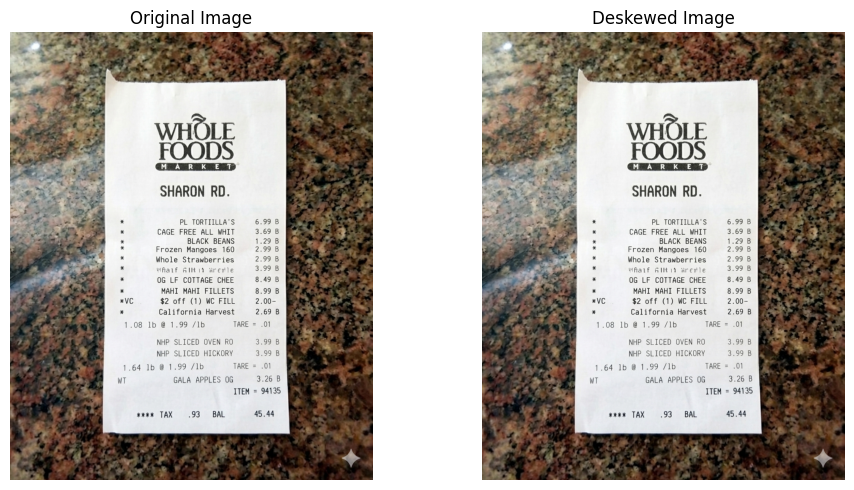

In [5]:
import matplotlib.pyplot as plt


def deskew(image):
    """
    Corrects skew in an image using minimum area rectangle.
    Returns:
        rotated image, detected angle
    """

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.bitwise_not(gray)

    thresh = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU
    )[1]

    coords = np.column_stack(np.where(thresh > 0))

    if len(coords) == 0:
        return image, 0

    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    rotated = cv2.warpAffine(
        image,
        M,
        (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )

    return rotated, angle
# ---------------- MAIN ---------------- #

#image_path = input("Enter image path: ")
#image = cv2.imread(image_path)
image = cv2.imread("/kaggle/input/datasets/musfiranazahat/new-rotated-image/Gemini_Generated_Image_5s6qdp5s6qdp5s6q.png")
if image is None:
    print("❌ Error: Image not found. Check the path.")
else:
    corrected, angle = deskew(image)

    print(f"📐 Detected skew angle: {angle:.2f} degrees")

    # Convert BGR → RGB for matplotlib display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    corrected_rgb = cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB)

    # Show images
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(corrected_rgb)
    plt.title("Deskewed Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

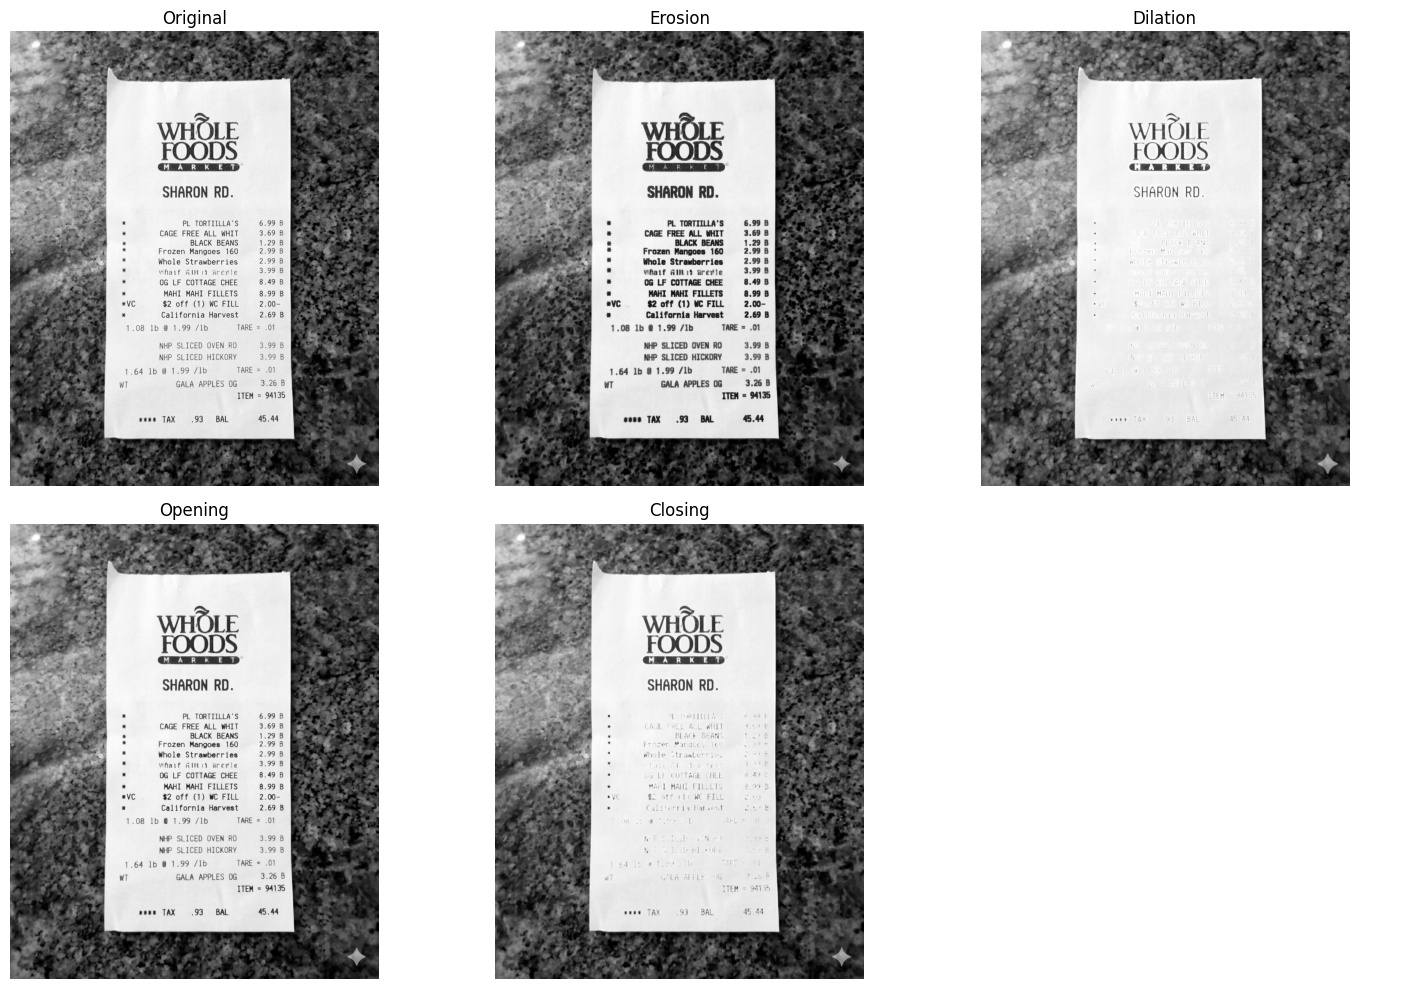

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('/kaggle/input/datasets/musfiranazahat/new-rotated-image/Gemini_Generated_Image_5s6qdp5s6qdp5s6q.png')

# Safety check
if img is None:
    raise ValueError("Image not found. Check the file path.")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Define kernel
kernel = np.ones((3, 3), np.uint8)

# Erosion - removes noise
erosion = cv2.erode(gray, kernel, iterations=1)

# Dilation - fills gaps
dilation = cv2.dilate(gray, kernel, iterations=1)

# Opening - erosion followed by dilation (removes small noise)
opening = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)
# Closing - dilation followed by erosion (fills small holes)
closing = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel)

# Plot results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(gray, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(erosion, cmap='gray')
axes[0, 1].set_title('Erosion')
axes[0, 1].axis('off')

axes[0, 2].imshow(dilation, cmap='gray')
axes[0, 2].set_title('Dilation')
axes[0, 2].axis('off')

axes[1, 0].imshow(opening, cmap='gray')
axes[1, 0].set_title('Opening')
axes[1, 0].axis('off')

axes[1, 1].imshow(closing, cmap='gray')
axes[1, 1].set_title('Closing')
axes[1, 1].axis('off')

# Hide unused subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

In [7]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Display dataset information
print(f"Training samples: {x_train.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")
print(f"Image shape: {x_train.shape[1:]}")

2026-04-28 03:32:31.528114: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777347151.759334      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777347151.824922      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777347152.383369      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777347152.383409      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777347152.383412      55 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 60000
Test samples: 10000
Image shape: (28, 28)


In [1]:
import numpy as np
from tensorflow import keras

# Reshape to add channel dimension (for CNN input)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Convert to float and normalize to range [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Convert labels to one-hot encoding
y_train = keras.utils.to_categorical(y_train, num_classes=10)
y_test = keras.utils.to_categorical(y_test, num_classes=10)

2026-04-28 03:33:37.953974: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777347218.157499      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777347218.218725      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777347218.690605      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777347218.690642      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777347218.690645      55 computation_placer.cc:177] computation placer alr

NameError: name 'x_train' is not defined

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

# Create model
model = keras.Sequential([
    
    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    
    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten and dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Display model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-28 03:33:01.749785: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [2]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

# Build model
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# Train
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1
)

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test accuracy:", test_acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1777347327.049877      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777347327.055859      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/10


I0000 00:00:1777347329.520969     127 service.cc:152] XLA service 0x7e8ce8002810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777347329.521023     127 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777347329.521031     127 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777347329.733761     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


 72/422 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6171 - loss: 1.3484

I0000 00:00:1777347330.558746     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8192 - loss: 0.6558 - val_accuracy: 0.9522 - val_loss: 0.1701
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9462 - loss: 0.1882 - val_accuracy: 0.9643 - val_loss: 0.1278
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9627 - loss: 0.1343 - val_accuracy: 0.9690 - val_loss: 0.1046
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9723 - loss: 0.1010 - val_accuracy: 0.9732 - val_loss: 0.0914
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9767 - loss: 0.0817 - val_accuracy: 0.9752 - val_loss: 0.0838
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9821 - loss: 0.0649 - val_accuracy: 0.9762 - val_loss: 0.0792
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9847 - loss: 0.0535 - val_accuracy: 0.9742 - val_loss: 0.0837
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9873 - loss: 0.0464 - val_accuracy: 0.9760 - val_

Lab 6 Summary: Advanced OCR + CNN
🎯 Objective
Improve OCR accuracy using image preprocessing
Build a CNN model to recognize handwritten digits
Understand how deep learning is used in OCR systems
🔧 Part 1: Image Preprocessing (35 min)
1️⃣ Perspective Correction
Fix images taken at angles
Convert skewed document → straight view
👉 Uses transformation (corner points → rectangle)
2️⃣ Automatic Deskewing
Detect rotation angle of text
Rotate image to make text horizontal
👉 Uses thresholding + angle detection
3️⃣ Morphological Operations

Used to clean noisy images:

Erosion → removes noise
Dilation → fills gaps
Opening → removes small noise
Closing → fills small holes

👉 Improves OCR accuracy

🤖 Part 2: CNN Model (40 min)
1️⃣ Load Dataset
Use MNIST handwritten digits dataset
2️⃣ Preprocessing
Normalize pixel values (0–1)
Reshape images (28×28×1)
Convert labels to categorical
3️⃣ CNN Architecture
Conv Layer → extract features
Pooling → reduce size
Dense layers → classification
Dropout → prevent overfitting
4️⃣ Training
Train model for ~10 epochs
Expected accuracy: 98%+